In [1]:
!pip install torchmetrics pesq

  Preparing metadata (setup.py) ... - \ done
  Created wheel for pesq: filename=pesq-0.0.4-cp310-cp310-linux_x86_64.whl size=114934 sha256=b70802b1920412f271a8516ae03909df224380658d288ede30756fc920a16948
  Stored in directory: /root/.cache/pip/wheels/c5/4e/2c/251524370c0fdd659e99639a0fbd0ca5a782c3aafcd456b28d
Successfully built pesq


In [2]:
!apt install -y libsox-dev




libsox-dev is already the newest version (14.4.2+git20190427-2+deb11u2ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.


In [3]:
import glob
from typing import TypedDict, Callable

from IPython.display import Audio, display, HTML

import os
import librosa
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.functional.audio import (
    signal_distortion_ratio,
    perceptual_evaluation_speech_quality,
    scale_invariant_signal_noise_ratio,
)


RANDOM_SEED = 42

# Audio Denoising with Deep Learning

## Introduction

The goal of this project is to perform denoising by estimating a clean voice signal from a noisy one. The dataset includes clean voice recordings and noisy versions with street ambiance. Each noisy signal corresponds to a clean reference, identified by matching filenames.

The Signal-to-Noise Ratio (SNR) of the signals ranges from 0 to 20 dB, simulating different noise levels. Testing data follows a similar structure to the training data.

### Evaluation Metrics

Four metrics, in addition to the loss function, will be used to evaluate performance:

SDR (Signal-to-Distortion Ratio): Measures the ratio of target signal power to distortion power.

NSDR (Normalized SDR): Shows improvement over the noisy input.

SI-SNR (Scale-Invariant SNR): Evaluates noise reduction, invariant to scaling differences.

PESQ (Perceptual Evaluation of Speech Quality): Rates speech quality on a scale of -0.5 to 4.5.

Metrics were chosen from WAVE-U-NET: A MULTI-SCALE NEURAL NETWORK FOR END-TO-END AUDIO SOURCE SEPARATION, ISMIR 2018 and TAS NEt : Y. Luo et Al., TaSNet: Time-Domain Audio Separation Network for Real-Time, Single-Channel Speech Separation, ICASSP 2018 

## Data Analysis

### SNR Distribution

In [4]:
DATA_ROOT = "/kaggle/input/dlts-denoising/denoising"

100%|██████████| 782/782 [00:14<00:00, 53.35it/s]


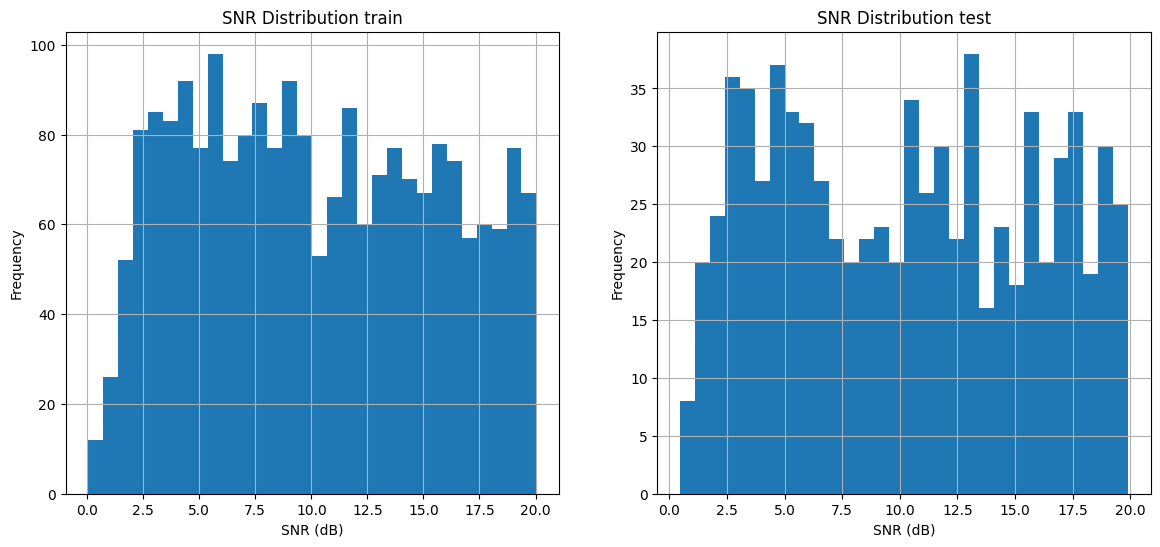

In [5]:
def calculate_snr(clean, noisy):
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean((noisy - clean) ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

def plot_snr_distribution(data_root, ax=None, name=""):
    snr_values = []
    
    clean_file_paths = list(glob.glob(data_root + "/clean/*.wav"))
    
    for clean_file_path in tqdm.tqdm(clean_file_paths):
        noisy_file_path = clean_file_path.replace("clean", "noisy")
        clean, _ = librosa.load(clean_file_path, sr=8000)
        noisy, _ = librosa.load(noisy_file_path, sr=8000)
    
        clean = clean / np.max(np.abs(clean))
        noisy = noisy / np.max(np.abs(noisy))

    
        snr = calculate_snr(clean, noisy)
        snr_values.append(snr)

    if ax is None:
        plt.figure(figsize=(8, 6))
        plt.hist(snr_values, bins=30)
        plt.title("SNR Distribution " + name)
        plt.xlabel("SNR (dB)")
        plt.ylabel("Frequency")
        plt.grid(True)
    else:
        ax.hist(snr_values, bins=30)
        ax.set_title("SNR Distribution " + name)
        ax.set_xlabel("SNR (dB)")
        ax.set_ylabel("Frequency")
        ax.grid(True)

f, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_snr_distribution(DATA_ROOT + "/train", axes[0], "train")
plot_snr_distribution(DATA_ROOT + "/test", axes[1], "test")

The SNR distribution across the dataset is relatively uniform within the expected range of 0 to 20 dB. However, there are fewer signals in the 0 to 2 dB range, suggesting that heavily degraded audio samples are rare. This could impact the model to generalize extreme noisy conditions.

### Wave form difference

In [6]:
sample = "Jules_Verne_-_L_ile_mysterieuse_Partie1_Chap01_0_.wav"
clean_path = DATA_ROOT + "/train/clean/" + sample
noisy_path = DATA_ROOT + "/train/noisy/" + sample

clean, clean_rate = librosa.load(clean_path, sr=8000)
noisy, noisy_rate = librosa.load(noisy_path, sr=8000)


display(HTML("<span>Clean</span>"))
display(Audio(clean, rate=clean_rate))

display(HTML("<span>Noisy</span>"))
display(Audio(noisy, rate=noisy_rate))

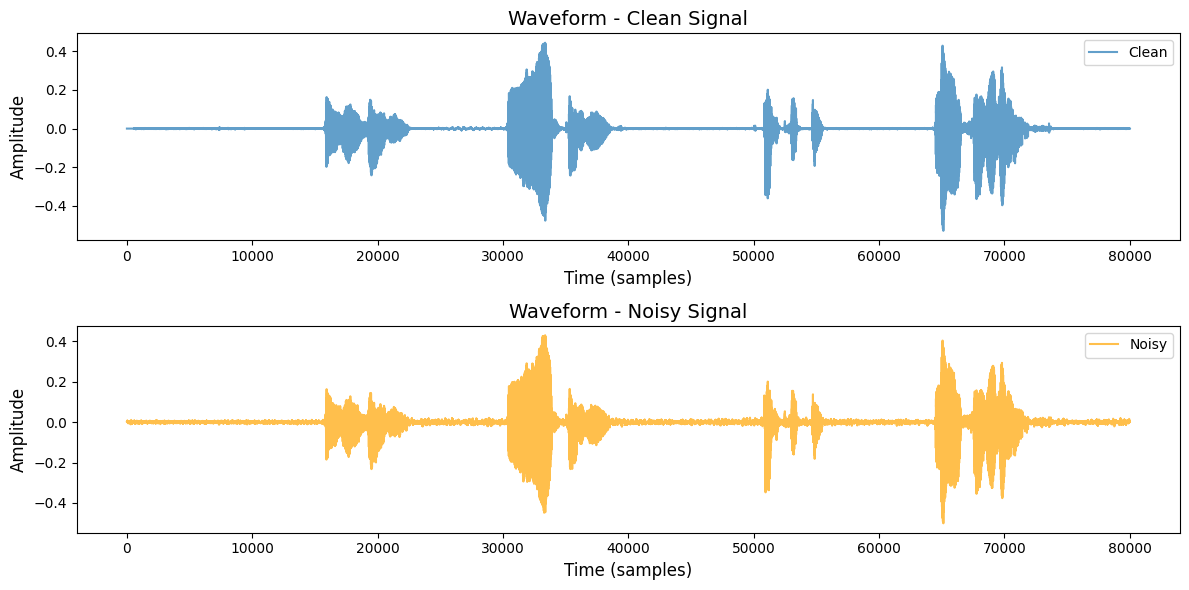

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(clean, label="Clean", alpha=0.7)
plt.title("Waveform - Clean Signal", fontsize=14)
plt.xlabel("Time (samples)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(noisy, label="Noisy", alpha=0.7, color="orange")
plt.title("Waveform - Noisy Signal", fontsize=14)
plt.xlabel("Time (samples)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In the waveform comparison, the clean signal shows distinct silent regions between speech segments and smooth amplitude transitions, indicative of minimal background noise.

In contrast, the noisy signal shows consistent background fluctuations, where the silent regions are less defined due to the added street ambiance noise.

### Spectrogram

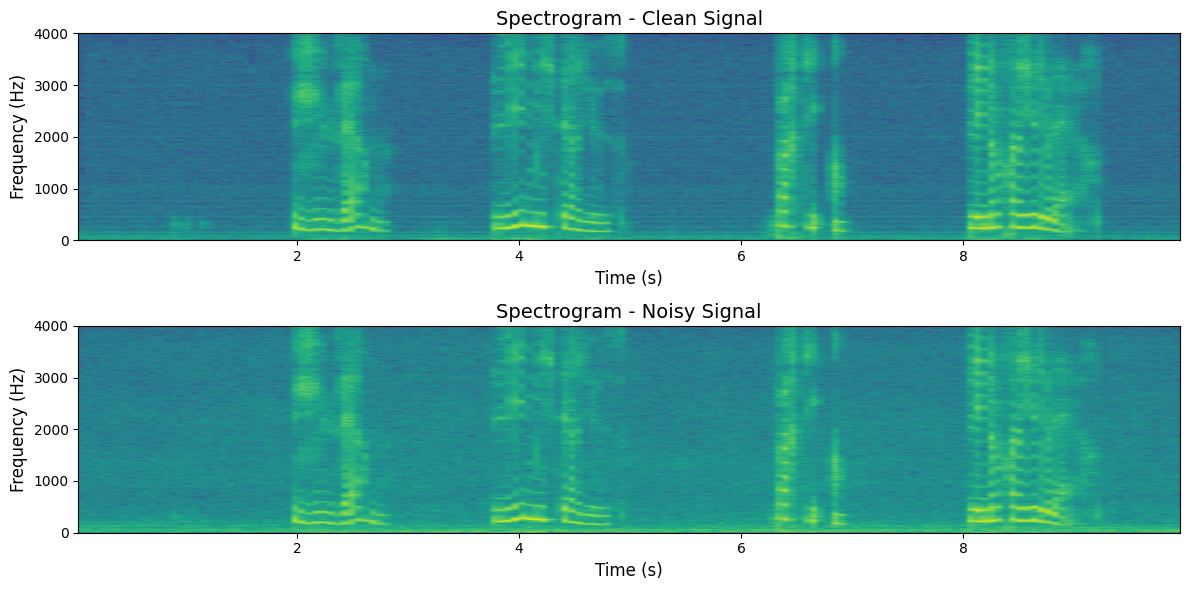

In [8]:
# Plot spectrograms
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.specgram(clean, Fs=clean_rate, NFFT=1024, noverlap=512, cmap="viridis")
plt.title("Spectrogram - Clean Signal", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Frequency (Hz)", fontsize=12)

plt.subplot(2, 1, 2)
plt.specgram(noisy, Fs=noisy_rate, NFFT=1024, noverlap=512, cmap="viridis")
plt.title("Spectrogram - Noisy Signal", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Frequency (Hz)", fontsize=12)
plt.tight_layout()
plt.show()

The spectrogram comparison reveals distinct differences between the clean and noisy signals.

In the clean spectrogram, the speech signal is well-defined, with clear harmonic structures across time and frequency. Silent regions are visible, with minimal background energy, indicating the absence of noise.

In contrast, the noisy spectrogram shows additional energy spread across the entire frequency range, particularly in the lower frequencies, which is characteristic of the street ambiance noise. The harmonics of the speech signal are still identifiable but are a bit obscured by the noise. Silent regions are less defined due to the constant presence of background energy.

## Data Loading

We will use two ways of loading our audio:

1. Signal Dataset which loads the audio, resample both clean and noisy signal to a given sample rate (by default 8khz) and returns it
2. Spectrogram Dataset which will also loads the audio but transforms them into spectrogram

### Signal dataset

In [9]:
class DenoisingSample(TypedDict):
    clean: torch.Tensor
    noisy: torch.Tensor


class SignalDenoisingDataset(Dataset):
    def __init__(self, root, sample_rate=8000, transform=None):
        self.sample_rate = sample_rate
        self.transform = transform

        self.file_list = glob.glob(f"{root}/clean/*.wav")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx) -> DenoisingSample:
        clean_path = self.file_list[idx]
        noisy_path = self.file_list[idx].replace("clean", "noisy")

        clean_audio, clean_rate = librosa.load(clean_path, sr=self.sample_rate)
        noisy_audio, noisy_rate = librosa.load(noisy_path, sr=self.sample_rate)

        clean_audio = torch.as_tensor(clean_audio).unsqueeze(0)
        noisy_audio = torch.as_tensor(noisy_audio).unsqueeze(0)

        if self.transform:
            clean_audio = self.transform(clean_audio)
            noisy_audio = self.transform(noisy_audio)

        return {
            "clean": clean_audio,
            "noisy": noisy_audio,
        }

### Spectrogram Dataset

In [ ]:
def load_audio_pair(clean_file, noisy_file, sr=16000):
    clean, _ = librosa.load(clean_file, sr=sr)
    noisy, _ = librosa.load(noisy_file, sr=sr)
    min_len = min(len(clean), len(noisy))
    clean = clean[:min_len]
    noisy = noisy[:min_len]
    return clean, noisy

def stft(y, n_fft, hop_length):
    return librosa.stft(y, n_fft=n_fft, hop_length=hop_length)

def istft(D, hop_length):
    return librosa.istft(D, hop_length=hop_length)

In [11]:
class SpecDenoiseDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000, n_fft=1024, hop_length=256, epsilon=1e-8):
        self.sample_rate = sr
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.epsilon = epsilon

        # Récupération des fichiers clean
        self.clean_files = glob.glob(os.path.join(root, "clean", "*.wav"))
        # Le dossier noisy est dérivé du chemin root
        self.noisy_dir = os.path.join(root, "noisy")

    def __len__(self):
        return len(self.clean_files)

    def __getitem__(self, idx):
        # Récupérer les chemins des fichiers clean et noisy
        clean_path = self.clean_files[idx]
        filename = os.path.basename(clean_path)
        noisy_path = os.path.join(self.noisy_dir, filename)

        # Charger les signaux audio
        clean_audio, noisy_audio = load_audio_pair(clean_path, noisy_path, sr=self.sample_rate)

        # Calculer les spectrogrammes STFT
        D_clean = stft(clean_audio, self.n_fft, self.hop_length)
        D_noisy = stft(noisy_audio, self.n_fft, self.hop_length)

        R_c, I_c = np.real(D_clean), np.imag(D_clean)
        R_n, I_n = np.real(D_noisy), np.imag(D_noisy)

        # Taille originale
        F_orig, T_orig = R_c.shape

        # Fonction pour ajouter du padding aux spectrogrammes
        def pad_spec(spec):
            Freq, Time = spec.shape
            Freq_pad = (4 - (Freq % 4)) % 4
            Time_pad = (4 - (Time % 4)) % 4
            if Freq_pad > 0 or Time_pad > 0:
                spec = np.pad(spec, ((0, Freq_pad), (0, Time_pad)), mode='constant')
            return spec

        # Padding des spectrogrammes
        R_c = pad_spec(R_c)
        I_c = pad_spec(I_c)
        R_n = pad_spec(R_n)
        I_n = pad_spec(I_n)

        # Calcul du masque complexe cible
        denom = R_n**2 + I_n**2 + self.epsilon
        M_real = (R_c * R_n + I_c * I_n) / denom
        M_imag = (I_c * R_n - R_c * I_n) / denom

        # Entrée et cible sous forme de tenseurs
        noisy_input = np.stack([R_n, I_n], axis=0)  # shape (2, F, T)
        mask_target = np.stack([M_real, M_imag], axis=0)

        noisy_input_t = torch.tensor(noisy_input, dtype=torch.float32)
        mask_target_t = torch.tensor(mask_target, dtype=torch.float32)

        return {
            "noisy": noisy_input_t,
            "clean": mask_target_t,
            "filename": filename,
            "F_orig": F_orig,
            "T_orig": T_orig,
            "R_noisy": R_n,
            "I_noisy": I_n,
        }

## Evaluation

To enable a fair evaluation process between our different models. We develop the following class which will compute and display the metrics we presented in the introduction in a similar manner.

In [12]:
def compute_metric(
        predicted_signal: torch.Tensor,
        clean_signal: torch.Tensor,
        noisy_signal: torch.Tensor,
        fs=8000,
    ):
        assert (
            len(predicted_signal.shape)
            == len(clean_signal.shape)
            == len(noisy_signal.shape)
            == 3
        )  # B, C, T

        sdr = signal_distortion_ratio(predicted_signal, clean_signal)
        sdr_noise = signal_distortion_ratio(noisy_signal, clean_signal)

        nsdr = sdr - sdr_noise

        pesq = perceptual_evaluation_speech_quality(
            predicted_signal, clean_signal, fs=fs, mode="nb"
        )

        si_snr = scale_invariant_signal_noise_ratio(predicted_signal, clean_signal)

        return {
            "sdr": sdr.item(),
            "nsdr": nsdr.item(),
            "si_snr": si_snr.item(),
            "pesq": pesq.item(),
        }

def evaluate(audio_root, predict_on_signal_function: Callable[[np.ndarray, int], np.ndarray], sr=8000):
    file_list = list(glob.glob(f"{audio_root}/clean/*.wav"))

    results = []
    for file_path in tqdm.tqdm(file_list):
        clean_path = file_path
        noisy_path = file_path.replace("clean", "noisy")

        clean_signal, _ = librosa.load(clean_path, sr=sr)
        noisy_signal, _ = librosa.load(noisy_path, sr=sr)

        predicted_signal = predict_on_signal_function(noisy_signal, sr)

        metrics = compute_metric(
            torch.as_tensor(predicted_signal).unsqueeze(0).unsqueeze(0),
            torch.as_tensor(clean_signal).unsqueeze(0).unsqueeze(0),
            torch.as_tensor(noisy_signal).unsqueeze(0).unsqueeze(0),
            fs=sr,
        )

        results.append(metrics)

    return pd.DataFrame(results)

### As a baseline, we will use a simple denoising algorithm

In [ ]:
def baseline_denoiser(audio, sr):
    """Baseline denoiser

    This denoiser is based on  “REPET-SIM” method of Rafii and Pardo, 2012, and inspired from
    https://librosa.org/librosa_gallery/auto_examples/plot_vocal_separation.html
    """
    S_full, phase = librosa.magphase(librosa.stft(audio))

    S_filter = librosa.decompose.nn_filter(S_full,
                                       aggregate=np.median,
                                       metric='cosine',
                                       width=int(librosa.time_to_frames(2, sr=sr)))

    S_filter = np.minimum(S_full, S_filter)

    margin_v = 5
    power = 2

    mask_v = librosa.util.softmask(S_full - S_filter,
                                margin_v * S_filter,
                                power=power)

    S_foreground = mask_v * S_full

    S_foreground_complex = S_foreground * np.exp(1j * phase)  # Combine magnitude and phase
    audio_foreground = librosa.istft(S_foreground_complex, length=len(audio))

    return audio_foreground

metrics = evaluate(DATA_ROOT + "/test", baseline_denoiser) # dummy evaluation
metrics.describe()

In [14]:
def display_prediction(denoised, noisy, clean, sr):
    display(HTML("<h1>Prediction</h1>"))

    display(HTML("<span>Noisy</span>"))
    display(Audio(noisy, rate=sr))

    display(HTML("<span>Target</span>"))
    display(Audio(clean, rate=sr))

    display(HTML("<span>Denoised</span>"))
    display(Audio(denoised, rate=sr))



In [15]:
denoised = baseline_denoiser(noisy, sr=8000)
display_prediction(denoised, noisy, clean, sr=8000)

## Training

To simplify training, we develop a trainer classes that will handle both signals and spectrogram models. We can easily try architectures, dataset and training hyper parameters.

In [16]:
class Trainer:
    def __init__(
        self,
        experiment: str,
        model: nn.Module,
        loss_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
        batch_size: int = 32,
        num_workers: int = 3,
        lr: float = 1e-3,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        logger: str = "tensorboard",
    ):
        self.experiment = experiment

        self.model = model.to(device)
        self.loss_fn = loss_fn
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.batch_size = batch_size
        self.num_workers = num_workers
        self.logger = logger
        self.writer = None
        self.device = device
        self.experiment_directory = f"experiments/{self.experiment}/"
        self.model_checkpoint_path = f"experiments/{self.experiment}/best.pth"
    
    def step(self, sample):
        noisy = sample["noisy"].to(self.device)
        clean = sample["clean"].to(self.device)

        outputs = self.model(noisy)

        loss = self.loss_fn(clean, outputs)

        return loss

    def log(self, name, value, step=None):
        if step is None:
            step = self.global_step

        if self.writer is not None:
            self.writer.add_scalar(name, value, step)

    def train_step(self, sample):
        self.optimizer.zero_grad()
        loss = self.step(sample)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, sample):
        with torch.no_grad():
            loss = self.step(sample)

        return loss.item()

    def run_epoch(self, loader, step_fn, epoch, prefix=""):
        losses = []
        for step, sample in enumerate(tqdm.tqdm(loader, total=len(loader), desc=prefix)):
            loss = step_fn(sample)
            losses.append(loss)
        return losses

    def fit(
        self,
        train_dataset: torch.utils.data.Dataset,
        val_dataset: torch.utils.data.Dataset,
        epochs: int = 10,
    ):
        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )
        val_loader = torch.utils.data.DataLoader(
            val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

        if self.logger == "tensorboard":
            self.writer = SummaryWriter(f"experiments/{self.experiment}/logs")

        best_eval_loss = float("inf")
        for epoch in range(epochs):
            self.model.train()
            train_losses = self.run_epoch(train_loader, self.train_step, epoch, "Train")
            train_loss = sum(train_losses) / len(train_losses)

            self.log("epochs/train_loss", train_loss, epoch)

            self.model.eval()
            val_losses = self.run_epoch(val_loader, self.val_step, epoch, "Validation")
            val_loss = sum(val_losses) / len(val_losses)

            self.log("epochs/val_loss", val_loss, epoch)

            if val_loss < best_eval_loss:
                best_eval_loss = val_loss
                torch.save(
                    self.model.state_dict(),
                    self.model_checkpoint_path,
                )

            print(
                f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
            )

### Signal based models

Similarly to Wave-U-Net$¹$. We employ a 1D Unet like architecture. We can configure:
* the number of blocks
* the number of filters for each blocks
* wether or not to use separable convolution

The model is implemented in the following code block


$¹$ Daniel Stoller, Sebastian Ewert, & Simon Dixon. (2018). Wave-U-Net: A Multi-Scale Neural Network for End-to-End Audio Source Separation.

In [17]:
class ConvBlock1D(nn.Module):
    """
    A block consisting of two convolutional layers followed by BatchNorm and ReLU activation.
    """

    def __init__(self, in_channels, out_channels):
        super(ConvBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.batchnorm1 = nn.BatchNorm1d(out_channels)
        self.batchnorm2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.batchnorm2(x)
        x = self.relu(x)
        return x


class SeparableConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SeparableConvBlock1D, self).__init__()
        self.depthwise1 = nn.Conv1d(
            in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels
        )
        self.pointwise1 = nn.Conv1d(in_channels, out_channels, kernel_size=1)

        self.depthwise2 = nn.Conv1d(
            out_channels, out_channels, kernel_size=3, padding=1, groups=out_channels
        )
        self.pointwise2 = nn.Conv1d(out_channels, out_channels, kernel_size=1)

        self.batchnorm1 = nn.BatchNorm1d(out_channels)
        self.batchnorm2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.depthwise1(x)
        x = self.pointwise1(x)
        x = self.batchnorm1(x)
        x = self.relu(x)
        x = self.depthwise2(x)
        x = self.pointwise2(x)
        x = self.batchnorm2(x)
        x = self.relu(x)
        return x


class Unet1D(nn.Module):
    """
    1D U-Net model for signal processing tasks.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        features=[64, 128, 256, 512],
        use_separable=False,
    ):
        """
        Parameters:
            in_channels: Number of input channels.
            out_channels: Number of output channels.
            features: List of feature map sizes for encoder/decoder.
        """
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.upsample = nn.Upsample(scale_factor=2, mode="linear", align_corners=True)

        convblock = ConvBlock1D if use_separable is False else SeparableConvBlock1D

        # Encoder: Downsampling path
        for feature in features:
            self.encoder.append(convblock(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = convblock(features[-1], features[-1] * 2)

        # Decoder: Upsampling path
        for feature in reversed(features):
            self.decoder.append(
                nn.ConvTranspose1d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(convblock(feature * 2, feature))

        # Final output layer
        self.final_layer = nn.Conv1d(features[0], out_channels, kernel_size=1)

        features_string = "-".join(map(str, features))
        self.name = f"Unet1D_{features_string}_{'separable' if use_separable else ''}"

    def forward(self, x):
        skip_connections = []

        # Encoder
        for enc_layer in self.encoder:
            x = enc_layer(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        skip_connections = skip_connections[::-1]  # Reverse skip connections
        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)  # Upsample
            skip_connection = skip_connections[idx // 2]
            if x.shape != skip_connection.shape:
                x = nn.functional.interpolate(x, size=skip_connection.shape[2])
            x = torch.cat((skip_connection, x), dim=1)  # Concatenate skip connection
            x = self.decoder[idx + 1](x)  # ConvBlock

        return self.final_layer(x)

    def predict_from_file(self, audio_file_path: str):
        audio, _ = librosa.load(audio_file_path, sr=8000)
        audio = torch.as_tensor(audio).unsqueeze(0).unsqueeze(0)
        audio = audio.to(self.final_layer.weight.device)

        previous_state = self.training
        self.eval()
        
        with torch.no_grad():
            out_audio = self(audio)

        self.train(previous_state)

        return out_audio[0, 0].detach().cpu().numpy()

In [18]:
dataset = SignalDenoisingDataset(root="/kaggle/input/dlts-denoising/denoising/train")

# We don't have a validation dataset so let's create one
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(RANDOM_SEED))

In [19]:
model = Unet1D(in_channels=1, out_channels=1)
trainer = Trainer(experiment=f"{model.name}", model=model, loss_fn=torch.nn.functional.l1_loss, batch_size=8)
trainer.fit(train_dataset=train_dataset, val_dataset=val_dataset)

# load best weights and set it to eval mode
model.load_state_dict(torch.load(trainer.model_checkpoint_path))
model = model.eval()

Train:   0%|          | 0/212 [00:00<?, ?it/s]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Train: 100%|██████████| 212/212 [06:21<00:00,  1.81s/it]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Validation: 100%|██████████| 53/53 [00:30<00:00,  1.74it/s]


Epoch 1/10 - Train Loss: 0.0213, Val Loss: 0.0135


Validation: 100%|██████████| 53/53 [00:30<00:00,  1.72it/s]


Epoch 2/10 - Train Loss: 0.0127, Val Loss: 0.0114


Validation: 100%|██████████| 53/53 [00:30<00:00,  1.72it/s]


...

Validation: 100%|██████████| 53/53 [00:30<00:00,  1.72it/s]


Epoch 9/10 - Train Loss: 0.0105, Val Loss: 0.0101


Validation: 100%|██████████| 53/53 [00:30<00:00,  1.73it/s]

Epoch 10/10 - Train Loss: 0.0106, Val Loss: 0.0109



/tmp/ipykernel_23/1303679793.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(trainer.model_checkpoint_path))


In [20]:
def unet1d_denoiser(model):
    def wrapper_unet1d_denoiser(audio, sr):
        with torch.no_grad():
            audio = torch.as_tensor(audio).unsqueeze(0).unsqueeze(0).to(model.final_layer.weight.device)
            denoised_signal = model(audio)
    
        return denoised_signal[0, 0].cpu().numpy()
    return wrapper_unet1d_denoiser

metrics = evaluate(DATA_ROOT + "/test", unet1d_denoiser(model)) # dummy evaluation
metrics.describe()

100%|██████████| 782/782 [03:09<00:00,  4.12it/s]


,sdr,nsdr,si_snr,pesq
count,782.000000,782.000000,782.000000,782.000000
mean,17.022030,7.076737,15.912089,2.383261
std,3.390988,3.662420,3.195724,0.536465
min,5.606481,-4.324895,4.916070,1.247103
25%,14.721313,4.515179,13.874657,1.931780
50%,17.844178,6.966237,16.602939,2.381176
75%,19.650735,9.815951,18.292393,2.813103
max,23.409147,15.952753,21.799162,3.642524


In [21]:
metrics.to_csv(trainer.experiment_directory + "/metrics.csv", index=False)

Let's listen to a prediction

In [22]:
test_dataset = SignalDenoisingDataset(root="/kaggle/input/dlts-denoising/denoising/test")
sample = test_dataset[0]
denoised = unet1d_denoiser(model)(sample["noisy"][0], sr=test_dataset.sample_rate)
display_prediction(denoised, sample["noisy"], sample["clean"], sr=test_dataset.sample_rate)

#### Reducing the number of filters

As the number of training sample is relatively small and the data is quite similar we might not need that amount of parameters to acheive similar performance.

In [23]:
model = Unet1D(in_channels=1, out_channels=1, features=[32, 64, 128, 256])
trainer = Trainer(experiment=f"{model.name}_v2", model=model, loss_fn=torch.nn.functional.l1_loss, batch_size=8)
trainer.fit(train_dataset=train_dataset, val_dataset=val_dataset)

# load best weights and set it to eval mode
model.load_state_dict(torch.load(trainer.model_checkpoint_path))
model.eval()

sample = test_dataset[0]
denoised = unet1d_denoiser(model)(sample["noisy"][0], sr=test_dataset.sample_rate)
display_prediction(denoised, sample["noisy"], sample["clean"], sr=test_dataset.sample_rate)

metrics = evaluate(DATA_ROOT + "/test", unet1d_denoiser(model)) # dummy evaluation
metrics.to_csv(trainer.experiment_directory + "/metrics.csv", index=False)
metrics.describe()

Train:   0%|          | 0/212 [00:00<?, ?it/s]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Train: 100%|██████████| 212/212 [02:08<00:00,  1.74it/s]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Validation: 100%|██████████| 53/53 [00:09<00:00,  5.47it/s]


Epoch 1/10 - Train Loss: 0.0199, Val Loss: 0.0124


Validation: 100%|██████████| 53/53 [00:09<00:00,  5.42it/s]


Epoch 2/10 - Train Loss: 0.0125, Val Loss: 0.0125


Validation: 100%|██████████| 53/53 [00:09<00:00,  5.43it/s]


...

Validation: 100%|██████████| 53/53 [00:09<00:00,  5.41it/s]

Epoch 10/10 - Train Loss: 0.0103, Val Loss: 0.0096



/tmp/ipykernel_23/4279538552.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(trainer.model_checkpoint_path))


100%|██████████| 782/782 [02:32<00:00,  5.13it/s]


,sdr,nsdr,si_snr,pesq
count,782.000000,782.000000,782.000000,782.000000
mean,16.671210,6.725918,15.704500,2.551148
std,3.113718,4.252664,3.042534,0.596022
min,8.301151,-8.735482,4.892602,1.242687
25%,14.529963,3.668239,13.799379,2.052608
50%,17.196968,6.867263,16.272450,2.589215
75%,19.139769,9.874418,18.006605,3.048282
max,22.292019,16.371098,21.406870,3.709048


#### Using Separable Convolution

Another way to increase performance is using separable convolution, so let's try it.

In [24]:
model = Unet1D(in_channels=1, out_channels=1, use_separable=True)
trainer = Trainer(experiment=f"l2_{model.name}", model=model, loss_fn=torch.nn.functional.l1_loss, batch_size=8)
trainer.fit(train_dataset=train_dataset, val_dataset=val_dataset)

# load best weights and set it to eval mode
model.load_state_dict(torch.load(trainer.model_checkpoint_path))
model.eval()

sample = test_dataset[0]
denoised = unet1d_denoiser(model)(sample["noisy"][0], sr=test_dataset.sample_rate)
display_prediction(denoised, sample["noisy"], sample["clean"], sr=test_dataset.sample_rate)

metrics = evaluate(DATA_ROOT + "/test", unet1d_denoiser(model)) # dummy evaluation
metrics.to_csv(trainer.experiment_directory + "/metrics.csv", index=False)
metrics.describe()

Train:   0%|          | 0/212 [00:00<?, ?it/s]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Train: 100%|██████████| 212/212 [04:44<00:00,  1.28s/it]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Validation: 100%|██████████| 53/53 [00:22<00:00,  2.32it/s]


Epoch 1/10 - Train Loss: 0.0219, Val Loss: 0.0123


Validation: 100%|██████████| 53/53 [00:23<00:00,  2.30it/s]


Epoch 2/10 - Train Loss: 0.0118, Val Loss: 0.0109


Validation: 100%|██████████| 53/53 [00:23<00:00,  2.30it/s]


...

Epoch 9/10 - Train Loss: 0.0103, Val Loss: 0.0100


Validation: 100%|██████████| 53/53 [00:23<00:00,  2.28it/s]
/tmp/ipykernel_23/2290564198.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

Epoch 10/10 - Train Loss: 0.0104, Val Loss: 0.0098


100%|██████████| 782/782 [03:09<00:00,  4.12it/s]


,sdr,nsdr,si_snr,pesq
count,782.000000,782.000000,782.000000,782.000000
mean,16.516311,6.571019,15.522475,2.582736
std,3.809973,4.770534,3.610929,0.655989
min,-2.183056,-16.133785,-3.624766,1.264904
25%,13.904230,3.950957,13.082276,2.037313
50%,17.108836,6.901047,16.169494,2.551815
75%,19.481353,9.789048,18.179910,3.084954
max,23.676096,16.660797,22.027777,4.042026


**L1 vs L2 loss**
Wave-U-Net used L2 loss but we tried L1 loss first. So now let's try the L2 loss

In [25]:
model = Unet1D(in_channels=1, out_channels=1)
trainer = Trainer(experiment=f"{model.name}", model=model, loss_fn=torch.nn.functional.mse_loss, batch_size=8)
trainer.fit(train_dataset=train_dataset, val_dataset=val_dataset)

# load best weights and set it to eval mode
model.load_state_dict(torch.load(trainer.model_checkpoint_path))
model.eval()

sample = test_dataset[0]
denoised = unet1d_denoiser(model)(sample["noisy"][0], sr=test_dataset.sample_rate)
display_prediction(denoised, sample["noisy"], sample["clean"], sr=test_dataset.sample_rate)

metrics = evaluate(DATA_ROOT + "/test", unet1d_denoiser(model)) # dummy evaluation
metrics.to_csv(trainer.experiment_directory + "/metrics.csv", index=False)
metrics.describe()

Train:   0%|          | 0/212 [00:00<?, ?it/s]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Train: 100%|██████████| 212/212 [06:37<00:00,  1.80s/it]/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Validation: 100%|██████████| 53/53 [00:30<00:00,  1.73it/s]


Epoch 1/10 - Train Loss: 0.0032, Val Loss: 0.0006


Validation: 100%|██████████| 53/53 [00:30<00:00,  1.73it/s]


Epoch 2/10 - Train Loss: 0.0007, Val Loss: 0.0005


Validation: 100%|██████████| 53/53 [00:30<00:00,  1.71it/s]


...

Validation: 100%|██████████| 53/53 [00:30<00:00,  1.72it/s]

Epoch 10/10 - Train Loss: 0.0005, Val Loss: 0.0004



/tmp/ipykernel_23/2587767225.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(trainer.model_checkpoint_path))


100%|██████████| 782/782 [03:10<00:00,  4.10it/s]


,sdr,nsdr,si_snr,pesq
count,782.000000,782.000000,782.000000,782.000000
mean,15.101823,5.156531,14.429566,2.413935
std,2.564356,4.173273,2.507613,0.448289
min,5.507222,-5.821443,5.391003,1.365943
25%,13.777712,2.006340,13.093081,2.060421
50%,15.934085,5.297215,15.210042,2.450804
75%,16.999787,8.269624,16.221446,2.770924
max,18.823233,14.558828,18.152109,3.496185


# Augmentation
Let's try to augment our dataset by adding additional noise over our noisy sample.

To do so, we will use the musan noise dataset that provides many different sound. We will randomly sample a sound from this dataset and add it to our training samples

In [13]:
class RandomNoiseTransform:
    def __init__(self, sample_rate, noise_dir, min_snr_db=0, max_snr_db=15):
        self.sample_rate = sample_rate
        self.min_snr_db = min_snr_db
        self.max_snr_db = max_snr_db
        
        self.noise_files_list = list(glob.glob(f'{noise_dir}/**/*.wav'))

    def __call__(self, audio_data):
        random_noise_file = random.choice(self.noise_files_list)
        effects = [
            ['remix', '1'], # convert to mono
            ['rate', str(self.sample_rate)], # resample
        ]
        noise, _ = torchaudio.sox_effects.apply_effects_file(random_noise_file, effects, normalize=True)
        audio_length = audio_data.shape[-1]
        noise_length = noise.shape[-1]
        if noise_length > audio_length:
            offset = random.randint(0, noise_length-audio_length)
            noise = noise[..., offset:offset+audio_length]
        elif noise_length < audio_length:
            noise = torch.cat([noise, torch.zeros((noise.shape[0], audio_length-noise_length))], dim=-1)

        snr_db = random.randint(self.min_snr_db, self.max_snr_db)
        snr = math.exp(snr_db / 10)
        audio_power = audio_data.norm(p=2)
        noise_power = noise.norm(p=2)
        scale = snr * noise_power / audio_power

        return (scale * audio_data + noise ) / 2


random_noise_transform = RandomNoiseTransform(sample_rate=8000, noise_dir="/kaggle/input/musan-noise/musan/noise")
transformed_audio = random_noise_transform(torch.as_tensor(noisy).unsqueeze(0))

display(HTML("<span>Clean</span>"))
display(Audio(noisy, rate=8000))

display(HTML("<span>Noisy</span>"))
display(Audio(transformed_audio[0], rate=8000))

In [14]:
dataset_augmented = SignalDenoisingDataset(root="/kaggle/input/dlts-denoising/denoising/train", transform=random_noise_transform)

# Let's recreate our datasets with augmentation
train_dataset_augmented, val_dataset_augmented = torch.utils.data.random_split(dataset_augmented, [0.8, 0.2], generator=torch.Generator().manual_seed(RANDOM_SEED))

In [15]:
model = Unet1D(in_channels=1, out_channels=1)
trainer = Trainer(experiment=f"augmented_{model.name}", model=model, loss_fn=torch.nn.functional.mse_loss, batch_size=8)
trainer.fit(train_dataset=train_dataset_augmented, val_dataset=val_dataset_augmented)

# load best weights and set it to eval mode
model.load_state_dict(torch.load(trainer.model_checkpoint_path))
model.eval()

sample = test_dataset[0]
denoised = unet1d_denoiser(model)(sample["noisy"][0], sr=test_dataset.sample_rate)
display_prediction(denoised, sample["noisy"], sample["clean"], sr=test_dataset.sample_rate)

metrics = evaluate(DATA_ROOT + "/test", unet1d_denoiser(model)) # dummy evaluation
metrics.to_csv(trainer.experiment_directory + "/metrics.csv", index=False)
metrics.describe()

### Spectrogram based models

The UNet model is an encoder-decoder architecture.

- Input: Takes a 2-channel input $(R_n, I_n)$

- Encoder: Two encoding blocks (enc1, enc2) with convolutional layers and ReLU activations, followed by MaxPooling to reduce resolution while increasing channels.

- Bottleneck: Extracts deep features with doubled channels.

- Decoder: Upsamples the features using bilinear interpolation and combines them with corresponding skip connections from the encoder to retain spatial details.

- Output: Produces a 2-channel output $(M_{\text{real}}, M_{\text{imag}})$

This structure allows the model to efficiently capture and reconstruct spatial information.

We took inspiration from **Wave-U-Net** and **Singing-voice-separation-with-U-Net**:

1. **Wave-U-Net: A Multi-Scale Neural Network for End-to-End Audio Source Separation**  
   *Daniel Stoller, Sebastian Ewert, & Simon Dixon (2018)*  
   [Paper](https://arxiv.org/abs/1806.03185) | [GitHub](https://github.com/f90/Wave-U-Net)  

2. **Singing Voice Separation with U-Net**  
   [GitHub Repository](https://github.com/Zhz1997/Singing-voice-speration-with-U-Net/tree/main)


In [ ]:
class UNet(nn.Module):
    def __init__(self, base_channels=64):
        super(UNet, self).__init__()
        
        self.enc1 = nn.Sequential(
            nn.Conv2d(2, base_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels, 3, padding=1),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d((2,2))

        self.enc2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels*2, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels*2, base_channels*2, 3, padding=1),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d((2,2))

        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*4, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels*4, base_channels*4, 3, padding=1),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.Conv2d(base_channels*4+base_channels*2, base_channels*2, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels*2, base_channels*2, 3, padding=1),
            nn.ReLU()
        )

        
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_channels*2+base_channels, base_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels, 2, 3, padding=1)  
        )

    def forward(self, x):
        x1 = self.enc1(x)  
        x2 = self.pool1(x1)
        x2 = self.enc2(x2)
        x3 = self.pool2(x2)
        x3 = self.bottleneck(x3)

        x3_up = F.interpolate(x3, size=x2.shape[2:], mode='bilinear', align_corners=True)
        x3_cat = torch.cat([x3_up, x2], dim=1)
        x3 = self.dec2(x3_cat)

        x3_up = F.interpolate(x3, size=x1.shape[2:], mode='bilinear', align_corners=True)
        x3_cat = torch.cat([x3_up, x1], dim=1)
        x3 = self.dec1(x3_cat)

        return x3

The spectrogram_loss_fn function defines a custom loss for spectrogram-based tasks. It computes the loss separately for the real and imaginary parts of the spectrogram.
The total loss is the sum of the real and imaginary losses, ensuring both components are optimized simultaneously.

In [30]:
def spectrogram_loss_fn(loss_fn):
    def spectrogram_loss(clean, outputs):
        loss_real = loss_fn(clean[:, 0:1, :, :], outputs[:, 0:1, :, :])  # Partie réelle
        loss_imag = loss_fn(clean[:, 1:2, :, :], outputs[:, 1:2, :, :])  # Partie imaginaire
        return loss_real + loss_imag
    return spectrogram_loss

# Training

Loading the data.

In [ ]:
sr = 16000
n_fft = 1024
hop_length = 256
epsilon = 1e-9 

spec_dataset = SpecDenoiseDataset(root="/kaggle/input/dlts-denoising/denoising/train", sr=sr, n_fft=n_fft, hop_length=hop_length)

train_dataset, val_dataset = torch.utils.data.random_split(spec_dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(RANDOM_SEED))

**L1-loss model**

In [32]:
model_spec = UNet()
spectrogram_l1_loss = spectrogram_loss_fn(F.l1_loss)
trainer_spec = Trainer(experiment=f"spectrogram_l1", model=model_spec, loss_fn=spectrogram_l1_loss, batch_size=4,num_workers =0)
trainer_spec.fit(train_dataset=train_dataset, val_dataset=val_dataset)

model_spec.load_state_dict(torch.load(trainer_spec.model_checkpoint_path))
model_spec = model_spec.eval()

Validation: 100%|██████████| 106/106 [00:38<00:00,  2.74it/s]


Epoch 1/10 - Train Loss: 0.3722, Val Loss: 0.3437


Validation: 100%|██████████| 106/106 [00:38<00:00,  2.75it/s]


Epoch 2/10 - Train Loss: 0.3394, Val Loss: 0.3413


Validation: 100%|██████████| 106/106 [00:38<00:00,  2.78it/s]


...

Validation: 100%|██████████| 106/106 [00:37<00:00,  2.80it/s]


Epoch 9/10 - Train Loss: 0.3305, Val Loss: 0.3358


Validation: 100%|██████████| 106/106 [00:38<00:00,  2.77it/s]

Epoch 10/10 - Train Loss: 0.3313, Val Loss: 0.3367



/tmp/ipykernel_23/3282724557.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_spec.load_state_dict(torch.load(trainer_spec.model_checkpoint_path))


We define another denoiser to have the same evaluation on both methods.

In [33]:
def unet_spectrogram_denoiser(model, sr=16000, n_fft=1024, hop_length=256):
    def wrapper_denoiser(noisy_audio: np.ndarray, sr=sr):

        if isinstance(noisy_audio, torch.Tensor):
            noisy_audio = noisy_audio.cpu().numpy()
            
        # SIFT
        D_noisy = stft(noisy_audio, n_fft=n_fft, hop_length=hop_length)
        R_n, I_n = np.real(D_noisy), np.imag(D_noisy)
        R_n = np.squeeze(R_n)
        I_n = np.squeeze(I_n)

        noisy_input = np.stack([R_n, I_n], axis=0)  # (2, F, T)
        noisy_input_t = torch.tensor(noisy_input, dtype=torch.float32).unsqueeze(0)  # (1, 2, F, T)

    
        device = next(model.parameters()).device
        noisy_input_t = noisy_input_t.to(device)
        # Prediction 
        model.eval()
        with torch.no_grad():
            pred_mask = model(noisy_input_t).squeeze(0).cpu().numpy()  # (2, F, T)

        # Reconstruction 
        M_real_est, M_imag_est = pred_mask[0], pred_mask[1]
        R_est = R_n * M_real_est - I_n * M_imag_est
        I_est = R_n * M_imag_est + I_n * M_real_est
        D_est = R_est + 1j * I_est  # Spectrogram

        # Reconstitution with ISTFT
        denoised_audio = istft(D_est, hop_length=hop_length)

        if len(denoised_audio) > len(noisy_audio):
            denoised_audio = denoised_audio[:len(noisy_audio)]
        elif len(denoised_audio) < len(noisy_audio):
            pad_length = len(noisy_audio) - len(denoised_audio)
            denoised_audio = np.pad(denoised_audio, (0, pad_length), mode='constant')
            
        return denoised_audio

    return wrapper_denoiser

In [34]:
metrics_spec = evaluate(DATA_ROOT + "/test", unet_spectrogram_denoiser(model_spec)) # dummy evaluation
metrics_spec.describe()

100%|██████████| 782/782 [02:56<00:00,  4.44it/s]


,sdr,nsdr,si_snr,pesq
count,782.000000,782.000000,782.000000,782.000000
mean,13.491878,3.546586,12.626492,2.731791
std,3.275081,4.079321,3.241381,0.663653
min,2.358567,-7.141017,1.704420,1.191781
25%,11.342789,0.378547,10.513978,2.224392
50%,13.849924,3.635015,13.075569,2.770254
75%,16.032388,6.495051,15.137019,3.222615
max,19.965904,13.695542,19.285215,4.170851


In [35]:
metrics_spec.to_csv(trainer_spec.experiment_directory + "/metrics_spec_l1.csv", index=False)

In [36]:
test_dataset = SpecDenoiseDataset(root="/kaggle/input/dlts-denoising/denoising/test", sr=sr, n_fft=n_fft, hop_length=hop_length)
sample = test_dataset[0]  

filename = sample["filename"]
clean_path = os.path.join(DATA_ROOT, "test/clean", filename)
noisy_path = os.path.join(DATA_ROOT, "test/noisy", filename)

clean_audio, noisy_audio = load_audio_pair(clean_path, noisy_path, sr=sr)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_spec = model_spec.to(device)
denoiser = unet_spectrogram_denoiser(model_spec, hop_length=hop_length)
denoised_audio = denoiser(noisy_audio, sr=sr)

display_prediction(denoised_audio, noisy_audio, clean_audio, sr=sr)

**L1 vs L2 loss**

In [37]:
model_spec = UNet()
spectrogram_mse_loss = spectrogram_loss_fn(F.mse_loss)
trainer_spec = Trainer(experiment=f"spectrogram_mse", model=model_spec, loss_fn=spectrogram_mse_loss, batch_size=4,num_workers =0)
trainer_spec.fit(train_dataset=train_dataset, val_dataset=val_dataset)

model_spec.load_state_dict(torch.load(trainer_spec.model_checkpoint_path))
model_spec = model_spec.eval()

sample = test_dataset[0]  

filename = sample["filename"]
clean_path = os.path.join(DATA_ROOT, "test/clean", filename)
noisy_path = os.path.join(DATA_ROOT, "test/noisy", filename)

clean_audio, noisy_audio = load_audio_pair(clean_path, noisy_path, sr=sr)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_spec = model_spec.to(device)
denoiser = unet_spectrogram_denoiser(model_spec, hop_length=hop_length)
denoised_audio = denoiser(noisy_audio, sr=sr)

display_prediction(denoised_audio, noisy_audio, clean_audio, sr=sr)

Validation: 100%|██████████| 106/106 [00:39<00:00,  2.72it/s]


Epoch 1/10 - Train Loss: 2.4917, Val Loss: 2.2767


Validation: 100%|██████████| 106/106 [00:38<00:00,  2.72it/s]


Epoch 2/10 - Train Loss: 2.4492, Val Loss: 2.2619


Validation: 100%|██████████| 106/106 [00:39<00:00,  2.70it/s]


...

Validation: 100%|██████████| 106/106 [00:38<00:00,  2.74it/s]


Epoch 9/10 - Train Loss: 2.4342, Val Loss: 2.2574


Validation: 100%|██████████| 106/106 [00:38<00:00,  2.75it/s]

Epoch 10/10 - Train Loss: 2.4322, Val Loss: 2.2501



/tmp/ipykernel_23/3395355923.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_spec.load_state_dict(torch.load(trainer_spec.model_checkpoint_path))


In [38]:
metrics_spec = evaluate(DATA_ROOT + "/test", unet_spectrogram_denoiser(model_spec)) # dummy evaluation
metrics_spec.describe()

100%|██████████| 782/782 [02:47<00:00,  4.66it/s]


,sdr,nsdr,si_snr,pesq
count,782.000000,782.000000,782.000000,782.000000
mean,15.513700,5.568408,14.724400,2.945812
std,3.944216,3.127326,3.780908,0.582104
min,3.602088,-4.237240,3.369632,1.366452
25%,12.694363,3.284569,11.965940,2.530613
50%,16.113320,5.644502,15.414818,2.969663
75%,18.637880,7.953247,17.752516,3.367379
max,22.907705,14.708336,21.575657,4.278361


In [39]:
metrics_spec.to_csv(trainer_spec.experiment_directory + "/metrics_spec_mse.csv", index=False)

## Conclusion

#### Conclusion

We added the results of our experiments on signal data in the following table


| Model              | sdr   | nsdr | si_snr | pesq |
| ------------------ | ---- | ---- | ------ | ---- |
| Baseline           |4.541855 | -5.403437 | -45.073138 | 1.904571
| Unet1d l1      | **17.022030**     | **7.076737**      | **15.912089**	        | 2.383261      |
| Unet1d l2  | 15.101823      | 5.156531      | 14.429566        | 2.413935      |
| Unet1d (/2)        | 16.671210     | 6.725918      | 15.704500       | 2.551148      |
| Unet1d l1 (separable)       | 16.516311     | 6.571019      | 15.522475       | 2.582736     |
| Data augmentation | 15.705292       |   5.760000        | 14.856874        | 2.619593      |
| Unet spec l1        | 13.491878     | 3.546586     | 12.626492       | 2.731791     |
| Unet spec l2 | 15.513700	      | 5.568408      | 14.724400        |**2.945812**      |
			

Our experiments, inspired by the Wave-U-Net research paper, demonstrate that models using spectrogram-based approaches produce the best auditory results, as confirmed by the PESQ metric. The Unet spec l2 model achieves the highest PESQ score of 2.945812.

However, other metrics like SDR, NSDR, and SI-SNR do not capture the subjective auditory improvement, reinforcing the importance of PESQ.

To further enhance performance, we will combine data augmentation techniques with spectrogram-based models. we will also focus on fitting these models more effectively to optimize their results.